## LGBM & XGBM

#### Objective:

The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset. 


#### Exploratory Data Analysis (EDA):

##### 1.	Load the Titanic dataset using Python's pandas library.

In [1]:
import pandas as pd

# Load Titanic dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\diabetes (1).csv")

# Display first 5 rows
print(df.head())

# Display dataset information
print(df.info())

# Display shape of dataset
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

##### 2.	Check for missing values.

In [2]:
# Check missing values
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


##### 3.	Explore data distributions using histograms and box plots.

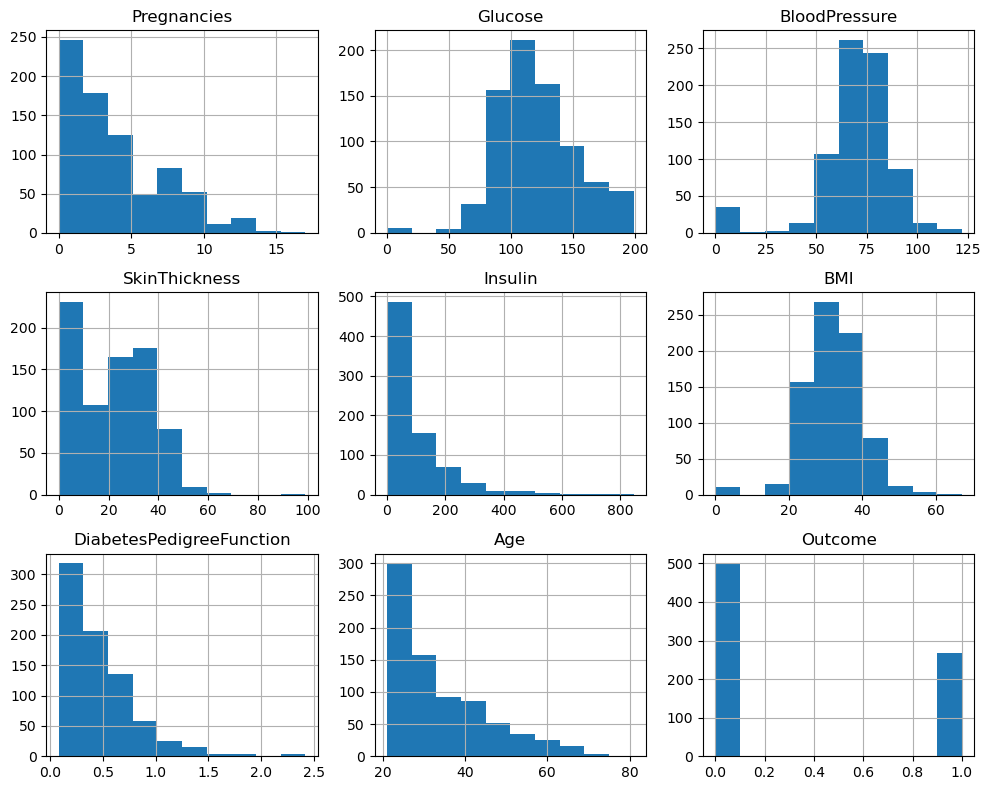

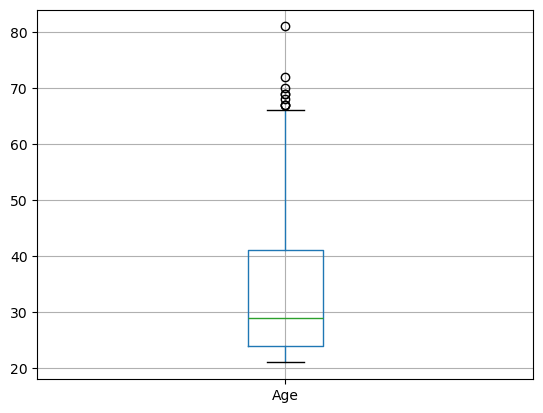

In [9]:
import matplotlib.pyplot as plt
# Load Titanic dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\diabetes (1).csv")

# Histograms
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Box plot for Age and Fare
cols = [col for col in ['Age', 'Fare'] if col in df.columns]

df[cols].boxplot()
plt.show()

##### 4.	Visualize relationships between features and survival using scatter plots and bar plots.

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


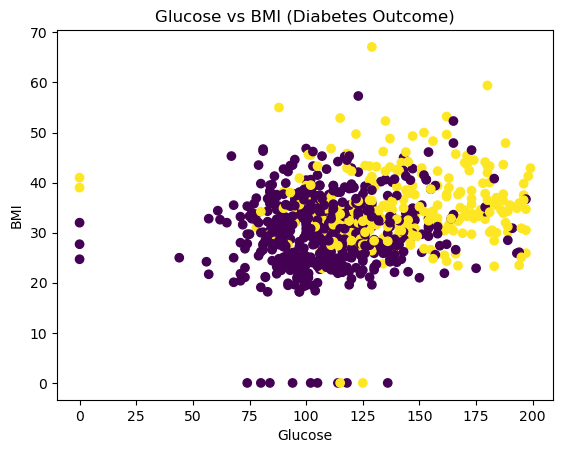

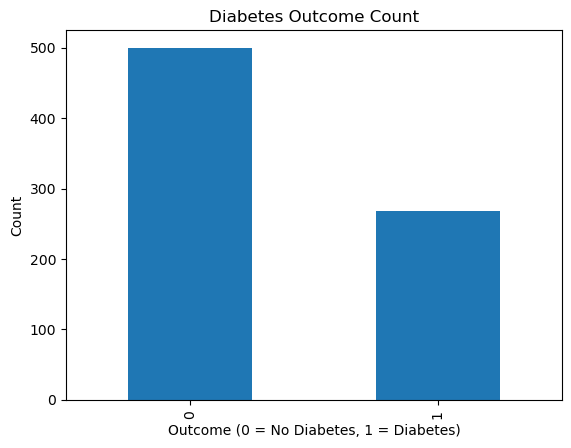

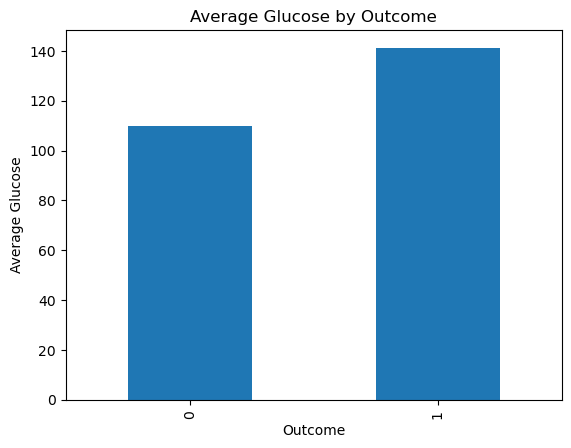

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\diabetes (1).csv")

# Check columns
print(df.columns)

# Scatter plot (Glucose vs BMI colored by Outcome)
plt.figure()
plt.scatter(df['Glucose'], df['BMI'], c=df['Outcome'])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI (Diabetes Outcome)")
plt.show()

# Bar plot (Outcome count)
df['Outcome'].value_counts().plot(kind='bar')
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.title("Diabetes Outcome Count")
plt.show()

# Bar plot (Average Glucose by Outcome)
df.groupby('Outcome')['Glucose'].mean().plot(kind='bar')
plt.xlabel("Outcome")
plt.ylabel("Average Glucose")
plt.title("Average Glucose by Outcome")
plt.show()

#### Data Preprocessing:

##### 1.	Impute missing values.

In [10]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\Rakshitha\Downloads\diabetes (1).csv")

# Columns where 0 means missing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Impute using median
df[cols] = df[cols].fillna(df[cols].median())

# Verify
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


##### 2.	Encode categorical variables using one-hot encoding or label encoding. 

In [11]:
# Check for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Display updated data
print(df.head())

Categorical Columns: Index([], dtype='object')
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


##### 3.	If needed you can apply more preprocessing methods on the given dataset.

In [13]:
from sklearn.preprocessing import StandardScaler

# Step 1: Replace 0 with NaN (for specific columns)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

# Step 2: Impute missing values (median)
df[cols] = df[cols].fillna(df[cols].median())

# Step 3: Outlier Handling using IQR (optional)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# Step 4: Feature Scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('Outcome', axis=1))

# Convert back to DataFrame
X = pd.DataFrame(scaled_features, columns=df.columns[:-1])
y = df['Outcome']

# Final output
print(X.head())
print(y.head())

   Pregnancies   Glucose  BloodPressure  SkinThickness  Insulin       BMI  \
0    -1.036184 -1.332802      -0.745427            0.0      0.0 -0.712466   
1     1.091586  2.315350      -0.947458            0.0      0.0 -1.252682   
2     0.179685 -0.178795       0.062699            0.0      0.0 -0.876168   
3     1.699521 -0.216021      -0.139332            0.0      0.0  0.711740   
4     1.091586  0.156239       2.285047            0.0      0.0  0.220635   

   DiabetesPedigreeFunction       Age  
0                 -0.056268 -0.407415  
1                  1.419818 -0.324793  
2                 -0.746028 -0.490038  
3                 -1.054121 -0.572661  
4                 -0.603477  1.492906  
1    0
2    1
5    0
7    0
9    1
Name: Outcome, dtype: int64


#### Building Predictive Models:

##### 1.	Split the preprocessed dataset into training and testing sets.

In [14]:
from sklearn.model_selection import train_test_split

# Preprocessing (same as before)
import numpy as np
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features and Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Output shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (162, 8)
X_test shape: (41, 8)


##### 2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6585365853658537
Precision: 0.5
Recall: 0.5714285714285714
F1 Score: 0.5333333333333333


##### 3.	Build predictive models using LightGBM and XGBoost algorithms.

In [17]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.2 MB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------- XGBoost ----------------
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

# ---------------- LightGBM ----------------
lgb_model = LGBMClassifier()
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
print("LightGBM Accuracy:", accuracy_score(y_test, lgb_pred))

XGBoost Accuracy: 0.6585365853658537
[LightGBM] [Info] Number of positive: 61, number of negative: 101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 162, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376543 -> initscore=-0.504247
[LightGBM] [Info] Start training from score -0.504247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

##### 4.	Train the models on the training set and evaluate their performance on the testing set.

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Model 
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

# LightGBM Model 
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

print("\nLightGBM Results:")
print("Accuracy:", accuracy_score(y_test, lgb_pred))
print("Precision:", precision_score(y_test, lgb_pred))
print("Recall:", recall_score(y_test, lgb_pred))
print("F1 Score:", f1_score(y_test, lgb_pred))

XGBoost Results:
Accuracy: 0.6585365853658537
Precision: 0.5
Recall: 0.7142857142857143
F1 Score: 0.5882352941176471
[LightGBM] [Info] Number of positive: 61, number of negative: 101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 162, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376543 -> initscore=-0.504247
[LightGBM] [Info] Start training from score -0.504247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

##### 5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Tuning 
xgb = XGBClassifier(eval_metric='logloss')

xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='accuracy')
xgb_grid.fit(X_train, y_train)

print("Best XGBoost Params:", xgb_grid.best_params_)
print("Best XGBoost Score:", xgb_grid.best_score_)

# LightGBM Tuning 
lgb = LGBMClassifier()

lgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [-1, 5],
    'learning_rate': [0.01, 0.1]
}

lgb_grid = GridSearchCV(lgb, lgb_params, cv=5, scoring='accuracy')
lgb_grid.fit(X_train, y_train)

print("\nBest LightGBM Params:", lgb_grid.best_params_)
print("Best LightGBM Score:", lgb_grid.best_score_)

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best XGBoost Score: 0.6971590909090909
[LightGBM] [Info] Number of positive: 48, number of negative: 81
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 180
[LightGBM] [Info] Number of data points in the train set: 129, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.372093 -> initscore=-0.523248
[LightGBM] [Info] Start training from score -0.523248
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

#### Comparative Analysis:

##### 1.	Compare the performance metrics (e.g., accuracy, precision, recall) of LightGBM and XGBoost models.

In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  XGBoost 
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

#  LightGBM 
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

# Metrics 
print("XGBoost Performance:")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall:", recall_score(y_test, xgb_pred))
print("F1 Score:", f1_score(y_test, xgb_pred))

print("\nLightGBM Performance:")
print("Accuracy:", accuracy_score(y_test, lgb_pred))
print("Precision:", precision_score(y_test, lgb_pred))
print("Recall:", recall_score(y_test, lgb_pred))
print("F1 Score:", f1_score(y_test, lgb_pred))

[LightGBM] [Info] Number of positive: 61, number of negative: 101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 162, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376543 -> initscore=-0.504247
[LightGBM] [Info] Start training from score -0.504247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

##### 2.	Visualize and interpret the results to identify the strengths and weaknesses of each algorithm.

[LightGBM] [Info] Number of positive: 61, number of negative: 101
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 162, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376543 -> initscore=-0.504247
[LightGBM] [Info] Start training from score -0.504247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

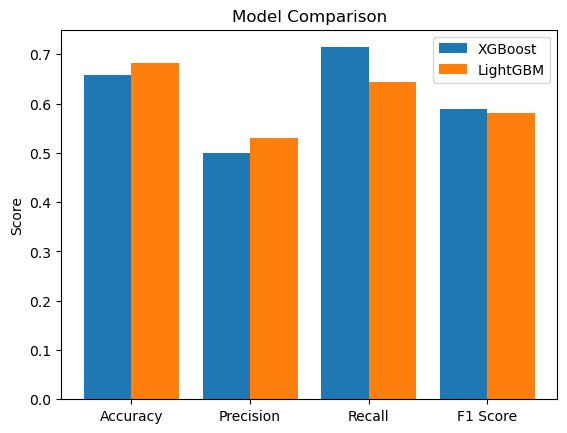

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Preprocessing
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

# Features & Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Models
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

lgb = LGBMClassifier()
lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

# Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

xgb_scores = [
    accuracy_score(y_test, xgb_pred),
    precision_score(y_test, xgb_pred),
    recall_score(y_test, xgb_pred),
    f1_score(y_test, xgb_pred)
]

lgb_scores = [
    accuracy_score(y_test, lgb_pred),
    precision_score(y_test, lgb_pred),
    recall_score(y_test, lgb_pred),
    f1_score(y_test, lgb_pred)
]

# Visualization
x = np.arange(len(metrics))

plt.figure()
plt.bar(x - 0.2, xgb_scores, 0.4, label='XGBoost')
plt.bar(x + 0.2, lgb_scores, 0.4, label='LightGBM')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.show()